In [1]:
# Imports
import ROOT
import array

from tools import scale_out as so

from emm import data as dat
from emm import fitting
from emm import models
from emm import signal_injection as si

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT.gErrorIgnoreLevel = ROOT.kWarning

fit_options = [
    ROOT.RooFit.PrintLevel(0),
]

Welcome to JupyROOT 6.30/04


In [2]:
# Load data
x = ROOT.RooRealVar("x", "Diphoton Mass [GeV]", 500, 10_000)
data_tree = dat.get_diphoton_data(tree=True)
diphoton_data = ROOT.RooDataSet("mgg", "mgg", ROOT.RooArgSet(x), ROOT.RooFit.Import(data_tree))
n = diphoton_data.numEntries()
data_mean = diphoton_data.mean(x)
print(f"Data mean: {data_mean}")

Data mean: 676.7652379849756


In [3]:
# Set up models
# toy_models = [
#     models.f1(x),
#     # models.f2(x),
#     # models.f3(x),
#     # models.f4(x),
# ]
toy_model = models.f1(x)

model_primitives = [
    models.ModelPrimitive(models.f1),
    models.ModelPrimitive(models.f2),
    models.ModelPrimitive(models.f3),
    models.ModelPrimitive(models.f4),
]
for k in range(2, 6):
    model_primitives.append(
        models.ModelPrimitive(
            models.ExponentialMixtureModel,
            k, data_mean=data_mean,
            name=f"ExponentialMixture-{k}"
        )
    )

# Fit toy models to data
# for toy_model in toy_models:
#     print(f"Fitting toy model: {toy_model.name}")
#     toy_model.pdf.fitTo(diphoton_data)
toy_model.pdf.fitTo(diphoton_data, *fit_options)

<cppyy.gbl.RooFitResult object at 0x(nil)>

[#1] INFO:NumericIntegration -- RooRealIntegral::init(f_1_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
Minuit2Minimizer: Minimize with max-calls 1000 convergence for edm < 1 strategy 1
Minuit2Minimizer : Valid minimum - status = 1
FVAL  = 31033.2097955985919
Edm   = 0.000159485240499530157
Nfcn  = 27
p1	  = 5.71808	 +/-  0.898473	(limited)
p2	  = -0.778647	 +/-  0.0667606	(limited)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization


Warning in <Minuit2>: MnPosDef Matrix forced pos-def by adding to diagonal 0.00459152
Warning in <Minuit2>: Minuit2Minimizer::Minimize Covar was made pos def


In [4]:
# Configuration
signal_points = [
    (600, 30),
    (800, 35),
    (1000, 40),
    (1200, 45),
    (1400, 50),
    (1600, 55),
    (1800, 60),
    (2000, 65),
]

# Fit configuration
n_restarts = 30
n_retries = 10

# Injection configuration
n_seeds = 20
n_toys_per_seed = 50
c_values = [0, 1, 2, 5]

# Test overrides
# n_seeds = 2
# n_toys_per_seed = 1
# c_values = [0, 5]

default_seed = 123456

# Use a distinct seed stream for injected toys so they are not identical to the
# background-only calibration toys (still fully reproducible).
np.random.seed(default_seed + 1)
seeds = np.random.randint(0, 10000, size=n_seeds)

In [5]:
# Step 1: Calibrate sigma_s
import os
import pickle

# Calibration configuration
calibration_n_seeds = 20
calibration_n_toys_per_seed = 20

calibration_seeds = np.random.randint(0, 10000, size=calibration_n_seeds)

calibration_file = f"{si.signal_injection_cache}/calibration_results.pkl"
if not os.path.exists(calibration_file):
    tasks = []
    for seed in calibration_seeds:
        task = so.Task(
            si.run_signal_injection_fits,
            x, toy_model,
            [models.ModelPrimitive(type(toy_model))],
            0, 
            seed,
            calibration_n_toys_per_seed,
            n,
            signal_points,
            n_restarts, n_retries,
            fit_options=fit_options,
            print_level=1,
            save_as=None
        )
        tasks.append(task)

    _calibration_results = so.run_tasks(tasks)
    # concatenate all calibration results into a single list
    calibration_results = []
    for i_seed, seed_results in enumerate(_calibration_results):
        for i_toy, i_toy_results in seed_results.items():
            for sp, sp_results in i_toy_results.items():
                for j_toy, j_toy_results in sp_results.items():
                    calibration_results.append({
                        "sp": sp,
                        "n_sig": j_toy_results["alt_n_sig"],
                    })
    calibration_df = pd.DataFrame(calibration_results)

    # Calculate sigma_s for each signal point
    sigma_s = {}
    for i, signal_point in enumerate(signal_points):
        signal_df = calibration_df[(calibration_df["sp"] == signal_point)]
        sigma_s[signal_point] = signal_df["n_sig"].std()
        print(f"Signal point {signal_point}: sigma_s = {sigma_s[signal_point]}")

    # Save sigma_s to a file
    with open(calibration_file, "wb") as f:
        pickle.dump(sigma_s, f)
else:
    # Load sigma_s from the file
    with open(calibration_file, "rb") as f:
        sigma_s = pickle.load(f)


In [6]:
# Run signal injection fits

tasks = []
for seed in seeds:
    for signal_point in signal_points:
        for c in c_values:
            task = so.Task(
                si.run_signal_injection_fits,
                x, toy_model,
                model_primitives,
                sigma_s[signal_point],
                c,
                seed,
                n_toys_per_seed,
                n,
                signal_point,
                n_restarts, n_retries,
                fit_options=fit_options,
                print_level=3,
            )
            tasks.append(task)

_ = so.run_tasks(
    tasks,
    use_condor=True,
    condor_job_name="signal_injection",
    env_wrapper=so.run_in_mamba,
    clear_logs=True
)

Submitting 640 tasks to condor with job name 'signal_injection'


In [ ]:
# Model selection cross check...
def model_selection(x, toy_model, seed):
    # Fit all models to the toy data and compare their AIC values
    aic_values = {}

    ROOT.RooRandom.randomGenerator().SetSeed(seed)
    toy_data = toy_model.pdf.generate(ROOT.RooArgSet(x), 5036)
    data_mean = toy_data.mean(x)

    for k in range(2, 7):
        mp = models.ModelPrimitive(
            models.ExponentialMixtureModel,
            k, data_mean=data_mean,
        )
        fit_result = fitting.fit_random_restarts(
            x, toy_data, mp,
            123,
            # 20, 5, (Old Settings)
            n_restarts, n_retries # Same settings as injection jobs
        )
        if fit_result is not None:
            n_params = 2*k-1
            aic = 2 * n_params - 2 * (-fit_result["nll"])
            aic_values[k] = aic

    return aic_values

base_seed = 42
n_toys = 100

tasks = []
for i in range(n_toys):
    seed = base_seed + i
    task = so.Task(
        model_selection,
        x, toy_model, seed
    )
    tasks.append(task)

ms_results = so.run_tasks(tasks)

In [13]:
# Count the number of times each model was selected as the best model
model_counts = {k: 0 for k in range(2, 6)}
for result in ms_results:
    if result is not None:
        best_model = min(result, key=result.get)
        model_counts[best_model] += 1

print("Model selection counts:", model_counts)

Model selection counts: {2: 49, 3: 49, 4: 2, 5: 0}


In [6]:
# Load results
results = []
for signal_point in signal_points:
    for c in c_values:
        results.extend(si.load_signal_injection_fit_results(
            toy_model,
            signal_point,
            c,
            seeds,
            n_toys_per_seed
        ))

results_df = pd.DataFrame(results)

In [7]:
# Do model selection
seeds = results_df["seed"].unique()

group_cols = ["signal_mean", "signal_width", "c", "seed", "toy_index"]

is_exp = results_df["bkg_model_name"].str.contains("ExponentialMixture")
exp_df = results_df[is_exp].copy()
non_exp_df = results_df[~is_exp].copy()

# Sanity check: every (signal point, c, seed, toy) group must have at least one
# ExponentialMixture fit, matching the per-group ValueError in the original loop.
all_groups = set(map(tuple, results_df[group_cols].drop_duplicates().itertuples(index=False, name=None)))
exp_groups = set(map(tuple, exp_df[group_cols].drop_duplicates().itertuples(index=False, name=None)))
missing_groups = all_groups - exp_groups
if missing_groups:
    raise ValueError(f"No ExponentialMixture model found for groups: {missing_groups}")

exp_df["k"] = exp_df["bkg_model_name"].str.split("-").str[-1].astype(int)
exp_df["n_params"] = 2 * exp_df["k"] - 1
exp_df["aic"] = 2 * exp_df["n_params"] + 2 * exp_df["bkg_only_nll"]
exp_df["bic"] = np.log(n) * exp_df["n_params"] + 2 * exp_df["bkg_only_nll"]

best_aic_df = exp_df.loc[exp_df.groupby(group_cols)["aic"].idxmin()].copy()
best_aic_df["bkg_model_name"] = "ExponentialMixture (AIC)"

best_bic_df = exp_df.loc[exp_df.groupby(group_cols)["bic"].idxmin()].copy()
best_bic_df["bkg_model_name"] = "ExponentialMixture (BIC)"

df = pd.concat([non_exp_df, best_aic_df, best_bic_df], ignore_index=True)

In [10]:
# Report how often each ExponentialMixture order k was selected by AIC, broken down by injection strength c
aic_counts_by_c = best_aic_df.groupby(["c", "k"]).size().unstack(fill_value=0)
aic_fractions_by_c = aic_counts_by_c.div(aic_counts_by_c.sum(axis=1), axis=0)

print("AIC selection counts by injection strength (c) and k:")
print(aic_counts_by_c)
print("\nAIC selection fractions by injection strength (c) and k:")
print(aic_fractions_by_c)

# c == 0 has no injected signal, so it is the closest apples-to-apples baseline
# for comparing against a pure background-only order-selection test.
print("\nAIC selection fractions for c == 0 (no injected signal):")
print(aic_fractions_by_c.loc[0])

AIC selection counts by injection strength (c) and k:
k     2     3     4     5
c                        
0  2030  1957  2016  1997
1  2034  2113  1966  1887
2  2059  2084  1948  1909
5  2063  2073  1969  1895

AIC selection fractions by injection strength (c) and k:
k         2         3         4         5
c                                        
0  0.253750  0.244625  0.252000  0.249625
1  0.254250  0.264125  0.245750  0.235875
2  0.257375  0.260500  0.243500  0.238625
5  0.257875  0.259125  0.246125  0.236875

AIC selection fractions for c == 0 (no injected signal):
k
2    0.253750
3    0.244625
4    0.252000
5    0.249625
Name: 0, dtype: float64


/tmp/ipykernel_1796982/1510664410.py:18: RuntimeWarning: invalid value encountered in sqrt
  metric = lambda row: np.sign(row["alt_n_sig"]-row["n_inj"])*np.sqrt(2*(-row["alt_nll"] + row["null_nll"]))


Plotting results for c = 0


/tmp/ipykernel_1796982/1510664410.py:18: RuntimeWarning: invalid value encountered in sqrt
  metric = lambda row: np.sign(row["alt_n_sig"]-row["n_inj"])*np.sqrt(2*(-row["alt_nll"] + row["null_nll"]))


Plotting results for c = 1
Plotting results for c = 2
Plotting results for c = 5


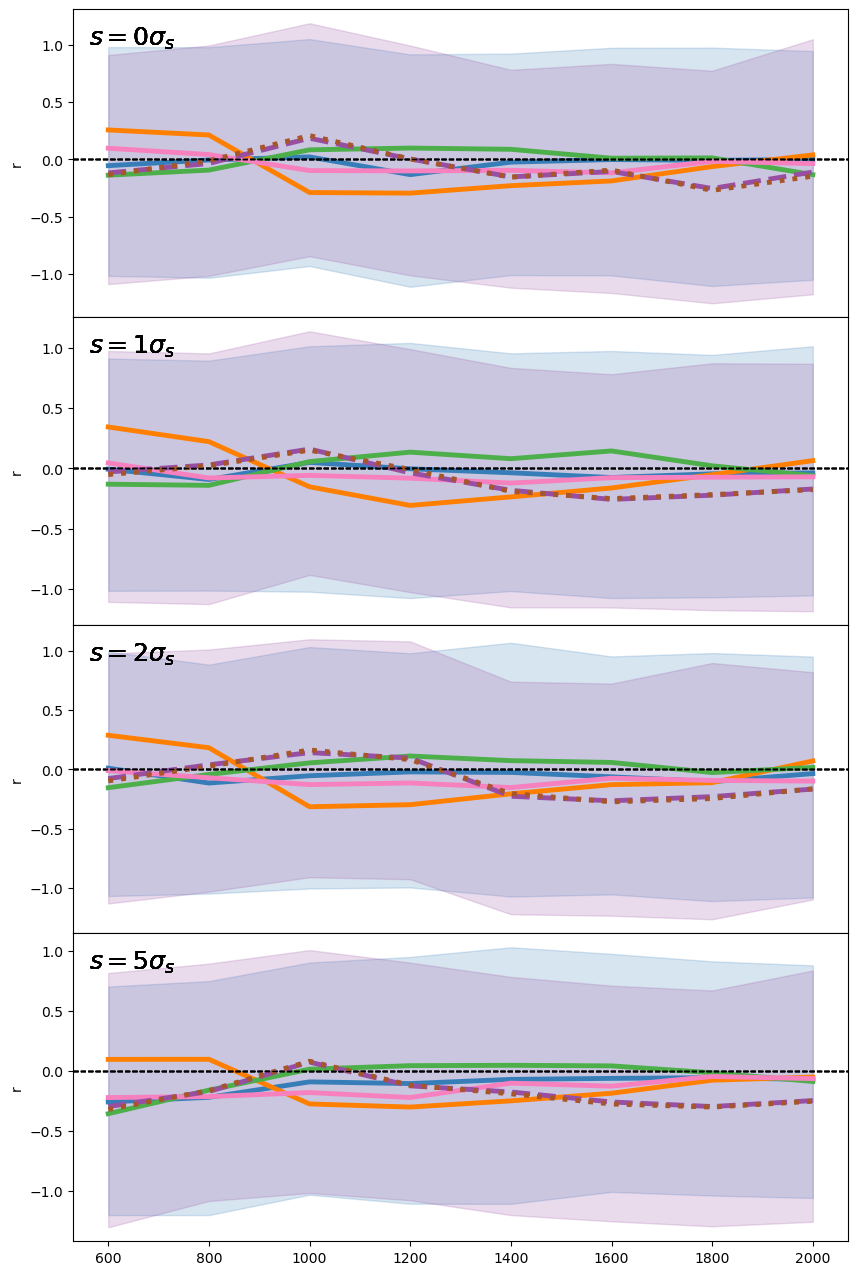

In [9]:
# Step 5: Plot recovered vs injected yield, per background family / truth model
fontsize, labelsize, linewidth, markersize = 18, 16, 3.5, 10

colors = {
    "f_1": '#377eb8', "f_2": '#ff7f00', "f_3": '#4daf4a', "f_4": '#f781bf',
    "ExponentialMixture (AIC)": '#984ea3',
    "ExponentialMixture (BIC)": '#a65628',
}
line_styles = {"f_1": 'solid', "f_2": 'solid', "f_3": 'solid', "f_4": 'solid',
               "ExponentialMixture (AIC)": 'dashed', "ExponentialMixture (BIC)": 'dotted'}

fig, axs = plt.subplots(
    len(c_values), 1,
    figsize=(10, 4*len(c_values)),
    sharex=True,
    gridspec_kw={'hspace': 0})

metric = lambda row: np.sign(row["alt_n_sig"]-row["n_inj"])*np.sqrt(2*(-row["alt_nll"] + row["null_nll"]))

df["metric"] = df.apply(metric, axis=1)
for i_c, c in enumerate(c_values):
    print(f"Plotting results for c = {c}")
    ax = axs[i_c]
    for bkg_model_name in df["bkg_model_name"].unique():
        model_results = df[df["bkg_model_name"] == bkg_model_name]

        xs = []
        ys = []
        y_lo = []
        y_hi = []

        for signal_point in signal_points:
            n_inj = c*sigma_s[signal_point]
            sp_results = model_results[
                (model_results["signal_mean"] == signal_point[0]) &
                (model_results["signal_width"] == signal_point[1]) &
                (model_results["c"] == c)
            ]
            if sp_results.empty:
                print(f"No results for signal point {signal_point} and n_inj {n_inj}. Skipping.")
                continue
            y = sp_results.apply(metric, axis=1).values
            y_med, y_low, y_high = np.nanpercentile(y, [50, 16, 84])
            xs.append(signal_point[0])
            ys.append(y_med)
            y_lo.append(y_low)
            y_hi.append(y_high)

        ax.plot(xs, ys, label=bkg_model_name, color=colors[bkg_model_name], linestyle=line_styles[bkg_model_name], linewidth=linewidth, markersize=markersize)
        if bkg_model_name in [toy_model.name, "ExponentialMixture (AIC)"]:
            ax.fill_between(xs, y_lo, y_hi, color=colors[bkg_model_name], alpha=0.2)

        # Dashed line at y=0
        ax.axhline(0, color='black', linestyle='dashed', linewidth=1)

        # Text in top left corner of each subplot indicating the value of c
        ax.text(0.02, 0.95, f"$s = {c} \\sigma_s$", transform=ax.transAxes, fontsize=fontsize, verticalalignment='top')

        ax.set_ylabel("r")

            



In [ ]:
# Now plot the pointwise power of the test statistic,
# i.e., the fraction of toys that exceed the 95% quantile of the background-only distribution.

